### Подготовка датасета по показателю объем убоя домашней птицы

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

from pylab import rcParams
from IPython.display import display
import math
from prophet import Prophet
pd.set_option('display.max_columns', 130)


import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.simplefilter("ignore", category=InterpolationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)



In [2]:
df = pd.read_excel("../../Data cleansing/output data/Просуммированные по категориям v2.xlsx")
df.head(5)

,Показатель,Регион,2015-01,2015-02,2015-03,2015-04,2015-05,2015-06,2015-07,2015-08,2015-09,2015-10,2015-11,2015-12,2016-01,2016-02,2016-03,2016-04,2016-05,2016-06,2016-07,2016-08,2016-09,2016-10,2016-11,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08,2018-09,2018-10,2018-11,2018-12,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,2019-11,2019-12,2020-01,2020-02,2020-03,2020-04,2020-05,2020-06,2020-07,2020-08,2020-09,2020-10,2020-11,2020-12,2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12,2022-01,2022-02,2022-03,2022-04,2022-05,2022-06,2022-07,2022-08,2022-09,2022-10,2022-11,2022-12,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07
0,Верблюды,АКМОЛИНСКАЯ ОБЛАСТЬ,NaN,NaN,0.40,NaN,NaN,NaN,0.09,1.00,NaN,NaN,0.20,NaN,NaN,0.18,0.28,NaN,NaN,0.40,NaN,NaN,0.65,NaN,0.31,1.00,NaN,NaN,NaN,NaN,NaN,2.01,NaN,1.20,NaN,NaN,2.18,0.39,NaN,NaN,1.04,NaN,0.14,2.08,NaN,NaN,NaN,NaN,NaN,0.30,NaN,NaN,NaN,0.66,NaN,0.33,NaN,0.9,NaN,NaN,NaN,10.08,NaN,NaN,NaN,NaN,NaN,0.54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Верблюды,АКТЮБИНСКАЯ ОБЛАСТЬ,101.98,67.47,374.84,115.59,218.72,14.15,19.77,3.00,39.16,46.16,238.56,463.35,109.04,72.94,384.96,114.35,221.89,10.93,18.79,3.50,38.53,46.64,216.08,472.07,110.32,68.17,380.15,127.12,217.61,14.98,21.26,7.14,44.63,51.78,239.43,513.33,115.70,69.40,371.53,130.17,218.41,14.59,21.76,7.19,45.97,55.48,252.68,527.66,117.94,70.37,385.75,117.80,218.45,15.54,21.78,7.2,47.06,58.02,257.54,543.35,119.80,71.3,396.90,121.8,228.10,15.90,21.9,7.2,63.00,59.90,260.20,552.10,121.60,71.8,398.40,128.50,228.80,13.10,22.50,7.20,63.90,61.90,150.70,554.90,121.30,73.3,404.20,128.70,234.90,13.60,23.60,6.3,49.80,62.4,153.70,552.8,118.07,69.17,384.21,121.01,223.46,11.76,21.39,5.52,48.18,61.39,150.87,531.79,119.50,72.60,391.0,126.1,229.10,12.2,24.10,5.7,49.87,63.00,154.3,538.40,129.3,77.60,411.5,128.1,235.70,12.2,25.17
2,Верблюды,АЛМАТИНСКАЯ ОБЛАСТЬ,1.00,0.20,51.60,25.40,NaN,61.90,76.87,95.57,16.09,0.10,10.80,46.78,15.06,13.70,131.80,9.20,17.89,130.12,2.00,NaN,4.99,2.06,4.90,44.48,15.06,23.94,41.60,19.54,3.00,15.14,18.50,14.82,14.52,12.60,9.92,43.11,20.72,2.96,15.24,NaN,1.00,20.03,3.44,7.77,117.25,1.00,NaN,20.34,21.95,3.04,17.91,26.81,9.16,18.80,13.37,NaN,17.29,15.90,4.69,23.10,10.85,9.7,42.75,NaN,6.21,21.10,4.0,2.6,28.10,4.53,79.50,93.18,23.70,11.2,16.00,2.00,3.10,19.62,2.30,4.85,11.18,2.80,9.65,36.44,10.60,11.5,26.10,7.20,12.75,11.20,11.20,27.0,25.26,17.9,21.90,12.5,16.55,16.81,22.78,12.10,12.44,6.85,39.65,17.22,8.85,27.48,0.48,29.72,18.90,17.40,12.5,16.4,11.60,16.7,15.70,24.0,7.70,6.90,5.4,12.60,22.6,19.00,8.2,12.0,40.70,41.6,28.10
3,Верблюды,АТЫРАУСКАЯ ОБЛАСТЬ,213.89,167.70,306.60,164.97,342.57,192.00,43.60,113.03,262.37,193.97,308.17,1087.33,325.10,190.60,301.10,154.84,328.50,220.30,66.10,118.20,234.90,196.51,270.92,974.18,303.30,167.41,323.54,182.34,349.10,249.40,57.57,88.40,221.21,199.63,278.80,964.02,305.22,159.62,326.87,159.50,367.20,257.50,60.01,78.10,253.27,332.00,355.05,989.86,280.08,165.05,334.51,134.85,367.97,321.22,126.22,93.7,263.10,366.66,348.54,1041.38,293.40,154.8,339.44,143.6,405.80,308.35,88.5,130.5,575.30,458.70,357.62,998.10,292.76,188.3,487.02,129.28,421.44,351.20,95.77,97.54,624.80,631.65,499.30,1179.66,286.67,189.8,513.16,171.46,402.10,432.22,121.53,126.2,637.50,651.7,482.94,1412.2,307.85,200.59,466.60,182.63,414.56,405.19,184.80,154.96,717.92,719.01,522.83,1164.77,323.81,423.76,441.9,219.1,487.69,446.9,191.43,133.5,730.34,709.68,537.6,

In [3]:
df['Показатель'].unique()

array(['Верблюды', 'КРС', 'Лошади', 'Молоко', 'Овцы и козы', 'Птица',
       'Свиньи', 'Яйца'], dtype=object)

In [4]:
df_bird = df[df['Показатель'].isin(['Птица'])]
df_bird.head()

,Показатель,Регион,2015-01,2015-02,2015-03,2015-04,2015-05,2015-06,2015-07,2015-08,2015-09,2015-10,2015-11,2015-12,2016-01,2016-02,2016-03,2016-04,2016-05,2016-06,2016-07,2016-08,2016-09,2016-10,2016-11,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08,2018-09,2018-10,2018-11,2018-12,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,2019-11,2019-12,2020-01,2020-02,2020-03,2020-04,2020-05,2020-06,2020-07,2020-08,2020-09,2020-10,2020-11,2020-12,2021-01,2021-02,2021-03,2021-04,2021-05,2021-06,2021-07,2021-08,2021-09,2021-10,2021-11,2021-12,2022-01,2022-02,2022-03,2022-04,2022-05,2022-06,2022-07,2022-08,2022-09,2022-10,2022-11,2022-12,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07
100,Птица,АКМОЛИНСКАЯ ОБЛАСТЬ,672.81,658.57,469.77,813.94,534.59,772.47,807.17,852.52,1056.11,1273.47,1092.41,1370.53,1212.69,995.62,1441.97,1074.47,1215.65,1481.78,1479.39,1503.93,1878.39,1541.00,1902.96,2090.63,1214.19,1425.48,1835.41,1855.06,2095.84,1991.31,1762.37,2372.74,1932.57,2120.83,2114.04,2497.50,1987.82,1826.53,1993.53,2161.83,2424.25,2083.51,2375.38,2527.27,2342.29,2494.96,4290.14,4268.20,4348.41,3974.87,4332.93,4717.47,4429.61,4320.12,5267.88,5456.57,4887.24,5539.59,5375.21,5718.05,4601.16,3950.34,6385.42,5288.46,5403.28,5687.65,5438.58,5829.94,5796.64,5938.57,5991.12,7490.12,7285.94,8654.03,9012.52,9093.87,9432.04,9302.50,8556.23,8998.01,9164.31,8767.83,8321.72,10144.63,8102.32,8471.43,9653.06,8452.34,8875.28,8968.60,9551.92,9282.26,8804.75,8955.52,8302.82,10574.58,8549.71,10767.77,9744.89,12187.63,11186.37,10310.86,10544.74,10428.33,10193.09,9808.32,9911.82,9807.18,8963.23,9586.12,10969.85,10894.97,10238.97,12692.46,10379.17,10080.07,10273.59,10251.41,8665.21,11438.74,8560.30,12551.51,12385.30,13015.90,10609.00,10408.60,10639.70
101,Птица,АКТЮБИНСКАЯ ОБЛАСТЬ,230.70,221.98,149.84,213.60,162.91,42.10,226.90,353.10,259.97,320.37,425.01,716.37,222.82,170.25,285.46,416.85,286.50,252.40,230.42,205.28,232.46,321.01,618.30,716.85,200.31,286.64,323.90,324.19,280.00,239.11,308.02,319.22,280.47,477.47,571.35,976.40,335.41,262.51,327.20,341.20,271.20,124.20,152.16,140.47,241.48,511.95,573.59,938.54,367.10,310.61,340.93,421.63,265.95,16.13,18.06,43.30,7.87,101.92,143.60,344.36,194.09,32.05,51.60,70.46,98.40,112.20,10.60,92.09,150.90,192.20,141.10,336.82,84.60,87.50,11.20,4.60,40.25,39.65,49.40,65.10,69.70,50.40,47.10,304.40,103.40,54.30,2.20,90.09,114.90,4.40,10.70,77.38,60.50,67.59,108.61,254.90,95.98,93.11,1.66,62.99,52.25,64.69,6.24,32.58,50.63,42.29,105.24,208.37,64.30,56.50,82.40,53.60,37.00,46.40,52.60,68.40,1.60,65.00,61.30,254.20,54.30,30.50,18.00,48.60,23.90,52.40,60.60
102,Птица,АЛМАТИНСКАЯ ОБЛАСТЬ,5624.73,5349.54,6376.58,6177.95,5994.10,7348.90,9177.65,6395.81,6796.17,7227.40,7430.24,14096.10,7208.81,7351.93,7272.70,7273.35,6956.71,7380.52,5906.20,6477.71,5941.33,5358.05,5978.39,6605.90,7207.01,6184.55,8207.21,7649.93,7434.13,9183.69,8139.04,7447.68,8117.38,8622.88,7503.10,7922.40,7991.20,6805.92,8525.86,9021.70,9223.69,8472.37,8407.70,7055.23,6245.91,6494.87,4631.31,7136.22,8759.54,8168.76,8841.15,9523.10,9109.75,7631.11,6718.79,7093.13,7562.55,8928.46,9393.52,10317.72,10107.30,8542.81,9194.10,9676.80,8860.70,9180.30,7975.70,7425.96,7645.90,8727.91,8680.13,9126.73,10777.41,9873.85,10072.20,8010.00,8686.50,10325.40,8276.00,9188.00,8394.00,8198.43,7181.40,9350.52,10369.50,9747.01,9057.67,11000.02,9581.11,10441.20,11155.97,9294.84,7848.10,7902.08,7385.88,9909.69,9853.61,8766.07,10536.30,8079.04,8838.75,9288.01,6586.60,7318.62,10417.50,10277.68,10783.51,11181.26,11949.02,10187.92,12341.77,11359.95,11464.21,11091.93,12311.95,11018.07,10774.72,11765.56,12546.48,12207.96,12023.33,10821.10,12752.96,13346.

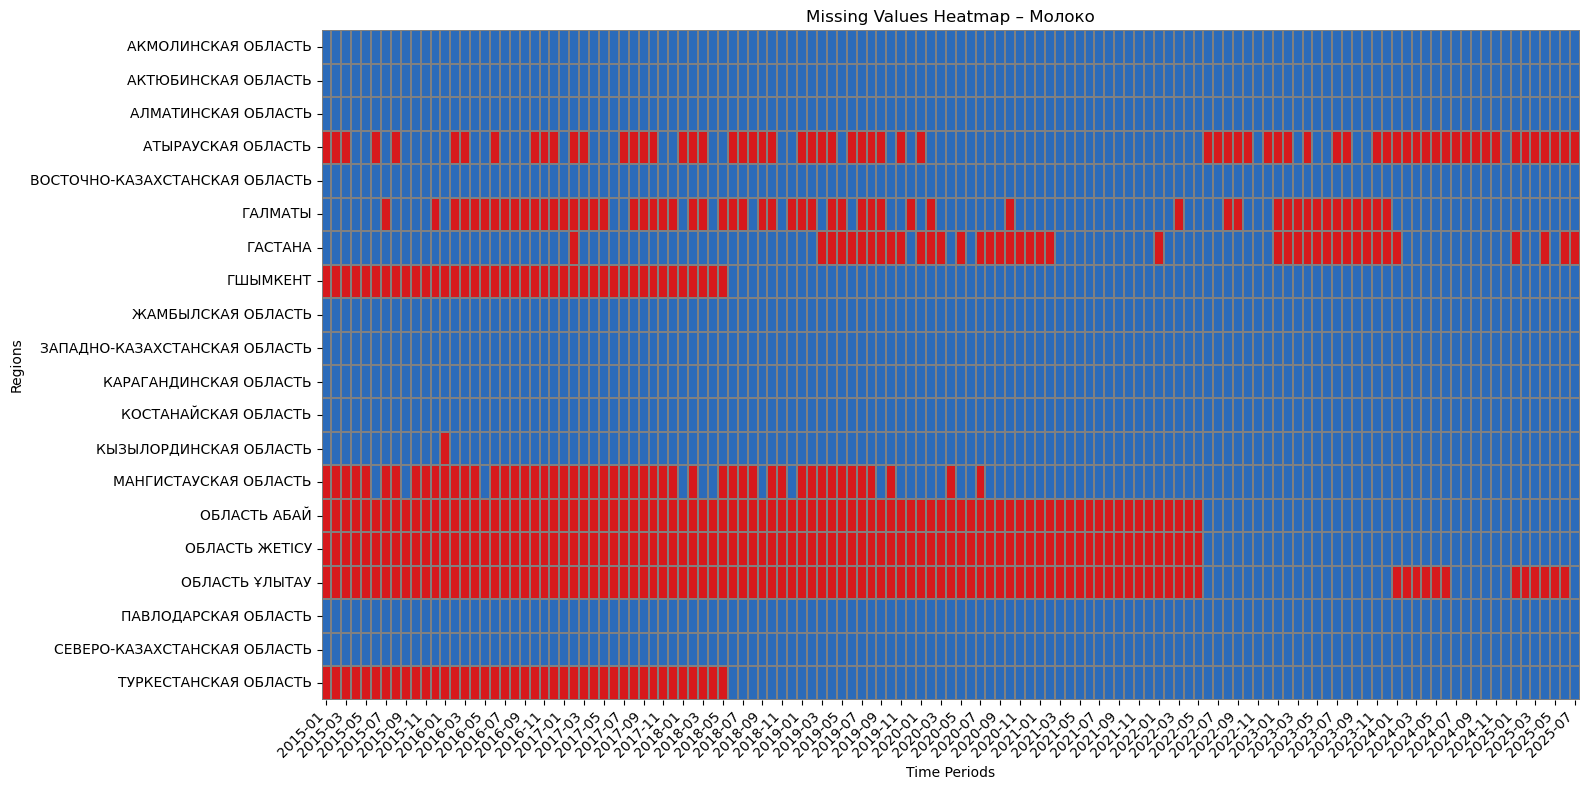

In [5]:
period_cols = [c for c in df_bird.columns if c not in ["Показатель", "Регион"]]
missing_matrix = (
    df_bird.set_index("Регион")[period_cols]
          .isna()
          .astype(int)
)
plt.figure(figsize=(16, 8))
sns.heatmap(
    missing_matrix,
    cmap=["#2b6bba", "#d7191c"],   # blue = data present, red = missing
    cbar=False,
    linewidths=0.3,
    linecolor="grey"
)

plt.title("Missing Values Heatmap – Молоко")
plt.xlabel("Time Periods")
plt.ylabel("Regions")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [6]:
df_bird.groupby("Регион").apply(lambda g: g.isna().sum().sum())

Регион
АКМОЛИНСКАЯ ОБЛАСТЬ                 0
АКТЮБИНСКАЯ ОБЛАСТЬ                 0
АЛМАТИНСКАЯ ОБЛАСТЬ                 0
АТЫРАУСКАЯ ОБЛАСТЬ                 66
ВОСТОЧНО-КАЗАХСТАНСКАЯ ОБЛАСТЬ      0
ГАЛМАТЫ                            56
ГАСТАНА                            40
ГШЫМКЕНТ                           41
ЖАМБЫЛСКАЯ ОБЛАСТЬ                  0
ЗАПАДНО-КАЗАХСТАНСКАЯ ОБЛАСТЬ       0
КАРАГАНДИНСКАЯ ОБЛАСТЬ              0
КОСТАНАЙСКАЯ ОБЛАСТЬ                0
КЫЗЫЛОРДИНСКАЯ ОБЛАСТЬ              1
МАНГИСТАУСКАЯ ОБЛАСТЬ              51
ОБЛАСТЬ АБАЙ                       89
ОБЛАСТЬ ЖЕТІСУ                     89
ОБЛАСТЬ ҰЛЫТАУ                    101
ПАВЛОДАРСКАЯ ОБЛАСТЬ                0
СЕВЕРО-КАЗАХСТАНСКАЯ ОБЛАСТЬ        0
ТУРКЕСТАНСКАЯ ОБЛАСТЬ              41
dtype: int64

In [7]:
# Step 1: Pivot to wide format (each indicator becomes columns of periods)
df_wide = df_bird.pivot(index="Регион", columns="Показатель")

# Step 2: Flatten multi-level columns: ('2015-01', 'КРС') → 'КРС_2015-01'
df_wide.columns = [f"{col[1]}_{col[0]}" for col in df_wide.columns]
df_wide = df_wide.reset_index()

# Step 3: Melt: one row per region-period-indicator
df_melted = df_wide.melt(id_vars="Регион", var_name="indicator_period", value_name="value")

# Step 4: Extract 'Период' and 'Показатель' from the combined column
df_melted["Период"] = df_melted["indicator_period"].str.extract(r"_(\d{4}-\d{2})$")
df_melted["Показатель"] = df_melted["indicator_period"].str.extract(r"^(.+)_\d{4}-\d{2}")

# Step 5: Pivot again to get final modeling format: one row per region+period, one column per indicator
df_bird = df_melted.pivot_table(index=["Регион", "Период"], columns="Показатель", values="value").reset_index()
print(df_bird.groupby("Регион").size().reset_index(name="Количество строк"))
df_bird

                            Регион  Количество строк
0              АКМОЛИНСКАЯ ОБЛАСТЬ               127
1              АКТЮБИНСКАЯ ОБЛАСТЬ               127
2              АЛМАТИНСКАЯ ОБЛАСТЬ               127
3               АТЫРАУСКАЯ ОБЛАСТЬ                61
4   ВОСТОЧНО-КАЗАХСТАНСКАЯ ОБЛАСТЬ               127
5                          ГАЛМАТЫ                71
6                          ГАСТАНА                87
7                         ГШЫМКЕНТ                86
8               ЖАМБЫЛСКАЯ ОБЛАСТЬ               127
9    ЗАПАДНО-КАЗАХСТАНСКАЯ ОБЛАСТЬ               127
10          КАРАГАНДИНСКАЯ ОБЛАСТЬ               127
11            КОСТАНАЙСКАЯ ОБЛАСТЬ               127
12          КЫЗЫЛОРДИНСКАЯ ОБЛАСТЬ               126
13           МАНГИСТАУСКАЯ ОБЛАСТЬ                76
14                    ОБЛАСТЬ АБАЙ                38
15                  ОБЛАСТЬ ЖЕТІСУ                38
16                  ОБЛАСТЬ ҰЛЫТАУ                26
17            ПАВЛОДАРСКАЯ ОБЛАСТЬ            

Показатель,Регион,Период,Птица
0,АКМОЛИНСКАЯ ОБЛАСТЬ,2015-01,672.81
1,АКМОЛИНСКАЯ ОБЛАСТЬ,2015-02,658.57
2,АКМОЛИНСКАЯ ОБЛАСТЬ,2015-03,469.77
3,АКМОЛИНСКАЯ ОБЛАСТЬ,2015-04,813.94
4,АКМОЛИНСКАЯ ОБЛАСТЬ,2015-05,534.59
...,...,...,...
1960,ТУРКЕСТАНСКАЯ ОБЛАСТЬ,2025-03,802.30
1961,ТУРКЕСТАНСКАЯ ОБЛАСТЬ,2025-04,750.07
1962,ТУРКЕСТАНСКАЯ ОБЛАСТЬ,2025-05,754.31
1963,ТУРКЕСТАНСКАЯ ОБЛАСТЬ,2025-06,925.67


In [8]:
df_bird['Регион'].nunique()

20

In [9]:
df_bird.to_excel("Датасет по птице v2.xlsx", index=False)

In [ ]:
# 1) приведение типов
df = df_bird.copy()
df["Период"] = pd.to_datetime(df["Период"], format="%Y-%m", errors="coerce")
df["Птица"] = pd.to_numeric(df["Птица"], errors="coerce")

# 2) wide-таблица: строки — месяцы, столбцы — регионы, значения — КРС
df_bird_wide = (df
        .pivot_table(index="Период", columns="Регион", values="Птица", aggfunc="sum")  # если дублей нет — можно aggfunc="first"
        .sort_index())
# 3) Убираем лишний уровень индекса у колонок
df_bird_wide.columns.name = None

# 4) Возвращаем "Период" в строковый формат YYYY-MM
df_bird_wide = df_bird_wide.reset_index()
df_bird_wide["Период"] = df_bird_wide["Период"].dt.strftime("%Y-%m")

df_bird_wide.to_excel("Датасет по птице wide.xlsx", index=False)
df_bird_wide